In [24]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures


BASE_DIR = "/Users/ipekgezer"
DATA_FILE = "country_year_women_ratio_vdem_multi.csv"

local_path = os.path.join(BASE_DIR, DATA_FILE)
fallback_path = "/mnt/data/country_year_women_ratio_vdem_multi.csv"  

DATA_PATH = local_path if os.path.exists(local_path) else fallback_path

df = pd.read_csv(DATA_PATH)

X_col = "v2x_polyarchy"       # or "v2x_libdem" 
y_col = "female_ratio"

# year filter
YEAR_MIN = 2000
if "year" in df.columns:
    df = df[df["year"] >= YEAR_MIN].copy()

df = df[df["year"] >= YEAR_MIN].copy()
df = df.groupby("country", as_index=False)[[X_col, y_col]].mean()


# Keeping only needed columns 
plot_df = df[[X_col, y_col]].dropna().copy()

X = plot_df[[X_col]].to_numpy()  # (n,1)
y = plot_df[y_col].to_numpy()    # (n,)

print("Rows used:", len(plot_df))
print("X range:", float(np.min(X)), "-", float(np.max(X)))
print("y range:", float(np.min(y)), "-", float(np.max(y)))


Rows used: 137
X range: 0.015 - 0.9195714285714286
y range: 0.0 - 0.5370370370370371


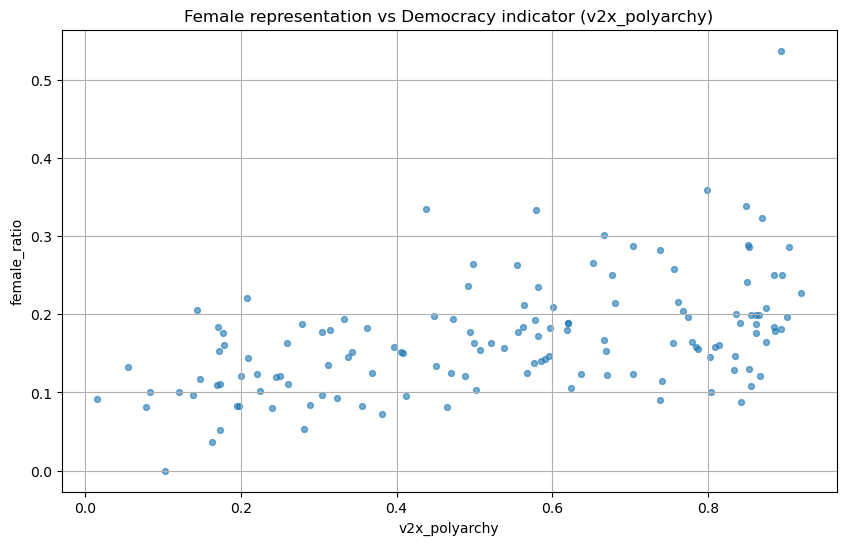

In [25]:
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.6, s=18)
plt.title(f"Female representation vs Democracy indicator ({X_col})")
plt.xlabel(X_col)
plt.ylabel("female_ratio")
plt.grid(True)
plt.show()


Linear  |  MSE=0.004265 RMSE=0.0653 R2=-0.0830
Poly d2 |  MSE=0.004309 RMSE=0.0656 R2=-0.0944


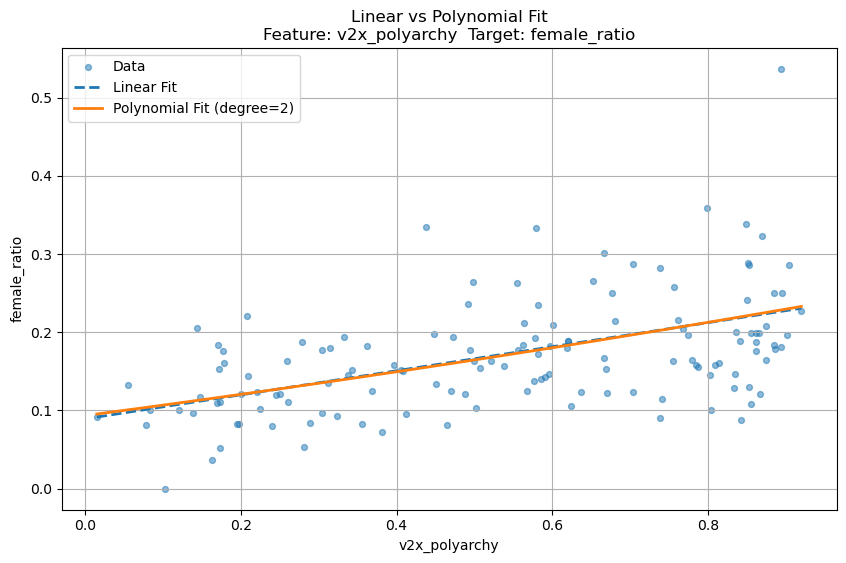

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# linear regression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# polynomial regression (degree=2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

lin_reg_poly = LinearRegression()
lin_reg_poly.fit(poly.fit_transform(X_train), y_train)

# test pred
y_test_pred_lin = lin_reg.predict(X_test)
y_test_pred_poly = lin_reg_poly.predict(poly.transform(X_test))

# metrics
mse_lin = mean_squared_error(y_test, y_test_pred_lin)
rmse_lin = np.sqrt(mse_lin)
r2_lin = r2_score(y_test, y_test_pred_lin)

mse_poly = mean_squared_error(y_test, y_test_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test, y_test_pred_poly)

print(f"Linear  |  MSE={mse_lin:.6f} RMSE={rmse_lin:.4f} R2={r2_lin:.4f}")
print(f"Poly d2 |  MSE={mse_poly:.6f} RMSE={rmse_poly:.4f} R2={r2_poly:.4f}")

x_min, x_max = float(X.min()), float(X.max())
X_new = np.linspace(x_min, x_max, 250).reshape(-1, 1)

y_lin_pred = lin_reg.predict(X_new)
y_poly_pred = lin_reg_poly.predict(poly.transform(X_new))

plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.5, s=18, label="Data")
plt.plot(X_new, y_lin_pred, linestyle="--", linewidth=2, label="Linear Fit")
plt.plot(X_new, y_poly_pred, linewidth=2, label="Polynomial Fit (degree=2)")
plt.title(f"Linear vs Polynomial Fit\nFeature: {X_col}  Target: {y_col}")
plt.xlabel(X_col)
plt.ylabel("female_ratio")
plt.legend()
plt.grid(True)
plt.show()


In [27]:
feat_names = poly.get_feature_names_out([X_col])

print("Intercept:", float(lin_reg_poly.intercept_))
for name, coef in zip(feat_names, lin_reg_poly.coef_):
    print(f"{name}: {coef:.6f}")


Intercept: 0.0933546796527799
v2x_polyarchy: 0.131053
v2x_polyarchy^2: 0.022482
